# 03 — Transfer Learning (Pathway A: Predictive Modeling)

## Project Setup (Required Fields)

**Project Pathway:** A — Predictive Modeling

**Dataset / Competition Name:** Skin Cancer MNIST: HAM10000  
**Source URL:** https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000

**Dataset Description (2–4 sentences):**  
HAM10000 is a dermatoscopic image dataset used for multi-class skin lesion classification. Each image corresponds to a skin lesion photographed under standardized dermoscopy conditions. Each row in the metadata file represents one image and includes the image ID, diagnosis label (7 classes), and patient-related attributes such as age, sex, and lesion localization. The goal is to learn a model that maps lesion images to the correct diagnosis class.

**Problem Statement (Pathway A):**  
We are predicting the lesion diagnosis class (`dx`) from dermatoscopic images. The target variable is a 7-class label: `akiec`, `bcc`, `bkl`, `df`, `mel`, `nv`, `vasc`. A model like this could support clinical triage by helping dermatology workflows prioritize suspicious lesions (not as a standalone diagnostic tool).

**Why deep learning is the right tool:**  
The input is image data with complex visual patterns (color, texture, borders, structures) that are difficult to capture with manual features. CNN-based deep learning models learn hierarchical visual features directly from pixels and typically outperform classical methods on medical image classification tasks.

**Evaluation metric and justification:**  
Primary metric during development: **Macro F1** (because the dataset is highly imbalanced and we care about minority classes, not only overall accuracy).  
We will also report accuracy for comparability with baselines.

**Personal connection or interest:**  
I’m interested in applying deep learning to real-world healthcare-style problems where interpretability (later via Grad-CAM) and model reliability matter, and this dataset provides a strong, well-known benchmark for that.

## Experiment Log (Required)

### Experiment 1: Transfer Learning Baseline (Frozen backbone)
**Date:**  
**Hypothesis:** A pretrained CNN will improve Macro F1 vs. the baseline CNN because it starts with strong general visual features.  
**Changes from previous:** Switch from custom CNN → pretrained backbone + new classifier head; freeze backbone.  
**LLM input:** Suggested by LLM, **modified** to track Macro F1 and keep test set untouched until the end.  
**Results:**
  - Training metric:
  - Validation metric:
**Conclusions:**  
**Next steps:**  

### Experiment 2: Fine-tuning (Unfreeze top layers)
**Date:**  
**Hypothesis:** Unfreezing the last block will adapt features to dermoscopy images and improve Macro F1.  
**Changes from previous:** Unfreeze last N layers / last block; lower learning rate.  
**LLM input:**  
**Results:**
  - Training metric:
  - Validation metric:
**Conclusions:**  
**Next steps:**  

### Experiment 3: Stronger Augmentation / Regularization
**Date:**  
**Hypothesis:** Stronger augmentation + regularization will reduce overfitting and improve validation Macro F1.  
**Changes from previous:** Add RandomResizedCrop / ColorJitter / RandomErasing and tune dropout/weight decay.  
**LLM input:**  
**Results:**
  - Training metric:
  - Validation metric:
**Conclusions:**  
**Next steps:**  

In [8]:
!rm -rf /content/drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# =========================
# Setup & Imports
# =========================

import os, random, time
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False  # faster + commonly used
torch.backends.cudnn.benchmark = True

# ---- Paths (match your Drive structure) ----
PROJECT_ROOT = "/content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000"
DATA_DIR = f"{PROJECT_ROOT}/data/raw/ham10000"
MODELS_DIR = f"{PROJECT_ROOT}/models"
RESULTS_DIR = f"{PROJECT_ROOT}/results"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- Device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)
print("✅ PROJECT_ROOT:", PROJECT_ROOT)
print("✅ DATA_DIR:", DATA_DIR)

✅ Device: cuda
✅ PROJECT_ROOT: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000
✅ DATA_DIR: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/data/raw/ham10000


In [11]:
import os

DATA_DIR = "/content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/data/raw/ham10000"

print("Files inside DATA_DIR:")
print(os.listdir(DATA_DIR))

Files inside DATA_DIR:
['HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_RGB.csv', 'hmnist_8_8_L.csv', 'skin-cancer-mnist-ham10000.zip', 'HAM10000_images_part_1', 'HAM10000_images_part_2', 'ham10000_images_part_1', 'ham10000_images_part_2']


In [12]:
# =========================
# Data loading + splits + DataLoaders
# =========================

metadata_path = f"{DATA_DIR}/HAM10000_metadata.csv"
assert os.path.exists(metadata_path), f"Metadata not found at {metadata_path}"

df = pd.read_csv(metadata_path)

part1 = f"{DATA_DIR}/HAM10000_images_part_1"
part2 = f"{DATA_DIR}/HAM10000_images_part_2"

def resolve_image_path(image_id: str) -> str:
    p1 = f"{part1}/{image_id}.jpg"
    if os.path.exists(p1):
        return p1
    p2 = f"{part2}/{image_id}.jpg"
    if os.path.exists(p2):
        return p2
    return None

df["image_path"] = df["image_id"].apply(resolve_image_path)
missing = df["image_path"].isna().sum()
print("❗ Missing image paths:", missing)
if missing:
    df = df.dropna(subset=["image_path"]).reset_index(drop=True)

# ---- Label encoding ----
classes = sorted(df["dx"].unique().tolist())
label_map = {c:i for i,c in enumerate(classes)}
df["label"] = df["dx"].map(label_map)

print("✅ Classes:", classes)
print("✅ Total rows:", len(df))

# ---- Stratified split: Train / Val / Test (same ratios as baseline) ----
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

print("\n✅ Split sizes:")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

# ---- Transforms (ResNet18 pretrained expects ImageNet-style normalization) ----
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class HamDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        y = int(row["label"])
        return img, y

BATCH_SIZE = 32
train_loader = DataLoader(HamDataset(train_df, train_tfms), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(HamDataset(val_df,   eval_tfms),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(HamDataset(test_df,  eval_tfms),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("\n✅ Batch shape:", xb.shape, "| Labels shape:", yb.shape)
print("✅ Label sample:", yb[:10].tolist())

❗ Missing image paths: 0
✅ Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
✅ Total rows: 10015

✅ Split sizes:
Train: 8012
Val:   1001
Test:  1002

✅ Batch shape: torch.Size([32, 3, 224, 224]) | Labels shape: torch.Size([32])
✅ Label sample: [5, 4, 4, 5, 5, 5, 5, 2, 5, 5]


In [13]:
# =========================
# Experiment 1: ResNet18 Transfer Learning (Frozen Backbone)
# =========================

# ---- Class weights from train split ----
counts = train_df["label"].value_counts().sort_index().values
counts_t = torch.tensor(counts, dtype=torch.float32)
class_weights = counts_t.sum() / (len(classes) * counts_t)
print("✅ Train counts:", counts.tolist())
print("✅ Class weights:", np.round(class_weights.numpy(), 3))

# ---- Model: ResNet18 pretrained ----
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Replace final layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, len(classes))

# Freeze backbone (everything except final layer)
for name, param in model.named_parameters():
    if not name.startswith("fc."):
        param.requires_grad = False

model = model.to(device)

# ---- Loss + optimizer ----
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Only train classifier head
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

# Optional scheduler (helps stabilize training)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=1
)

def train_one_epoch(model, loader):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    all_preds, all_true = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)

        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)

        all_preds.append(preds.cpu().numpy())
        all_true.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_true  = np.concatenate(all_true)

    acc = total_correct / total_n
    macro_f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)

    return total_loss / total_n, acc, macro_f1, all_true, all_preds

# ---- Training loop with checkpointing on best Val Macro F1 ----
EPOCHS = 5
best_val_f1 = -1.0

ckpt_path = f"{MODELS_DIR}/exp1_resnet18_frozen_best.pt"
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

print("✅ Experiment 1: training ResNet18 (frozen backbone)")
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc, va_f1, _, _ = eval_model(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1"].append(va_f1)

    # scheduler uses val F1 (macro)
    scheduler.step(va_f1)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train - loss: {tr_loss:.4f} | acc: {tr_acc:.4f}")
    print(f"Val   - loss: {va_loss:.4f} | acc: {va_acc:.4f} | macro_f1: {va_f1:.4f}")

    # checkpoint on best macro F1
    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "label_map": label_map,
            "classes": classes,
            "img_size": IMG_SIZE,
            "best_val_f1": best_val_f1
        }, ckpt_path)
        print(f"💾 Saved best checkpoint: {ckpt_path} (val_macro_f1={best_val_f1:.4f})")

print(f"\n✅ Training time: {time.time() - t0:.1f}s")
print("✅ Best Val Macro F1:", round(best_val_f1, 4))

✅ Train counts: [262, 411, 879, 92, 890, 5364, 114]
✅ Class weights: [ 4.369  2.785  1.302 12.441  1.286  0.213 10.04 ]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


✅ Experiment 1: training ResNet18 (frozen backbone)

Epoch 1/5
Train - loss: 1.5901 | acc: 0.5107
Val   - loss: 1.4648 | acc: 0.5544 | macro_f1: 0.3331
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/exp1_resnet18_frozen_best.pt (val_macro_f1=0.3331)

Epoch 2/5
Train - loss: 1.2589 | acc: 0.6055
Val   - loss: 1.2308 | acc: 0.5884 | macro_f1: 0.4298
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/exp1_resnet18_frozen_best.pt (val_macro_f1=0.4298)

Epoch 3/5
Train - loss: 1.1494 | acc: 0.6272
Val   - loss: 1.1630 | acc: 0.6224 | macro_f1: 0.4481
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/exp1_resnet18_frozen_best.pt (val_macro_f1=0.4481)

Epoch 4/5
Train - loss: 1.1371 | acc: 0.6216
Val   - loss: 1.2143 | acc: 0.6244 | macro_f1: 0.4776
💾 Saved best checkpoint: /content/drive/MyDrive/Data science clas

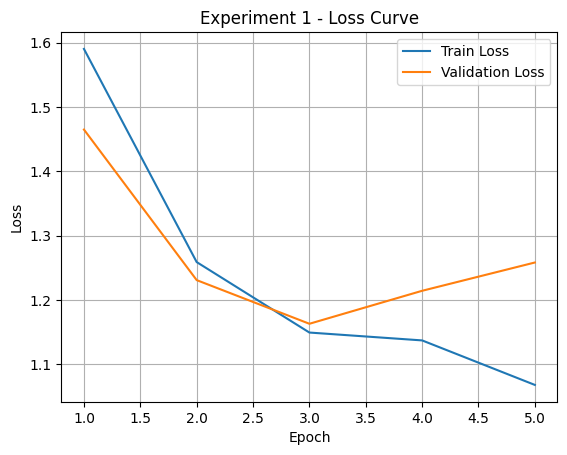

✅ Loss curve saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/exp1_loss_curve.png


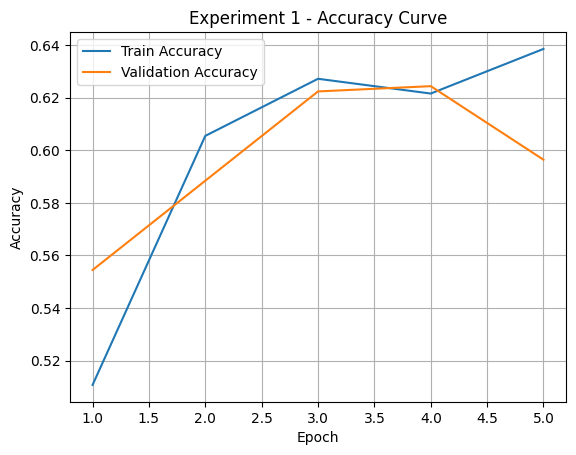

✅ Accuracy curve saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/exp1_accuracy_curve.png


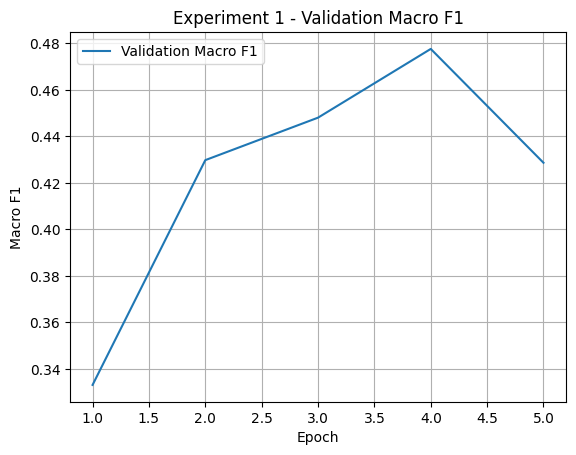

✅ Macro F1 curve saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/exp1_macro_f1_curve.png


In [14]:
# =========================
# Save Training Curves
# =========================

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

# ---- Loss curve ----
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 1 - Loss Curve")
plt.legend()
plt.grid(True)

loss_path = f"{RESULTS_DIR}/exp1_loss_curve.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Loss curve saved to:", loss_path)


# ---- Accuracy curve ----
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 1 - Accuracy Curve")
plt.legend()
plt.grid(True)

acc_path = f"{RESULTS_DIR}/exp1_accuracy_curve.png"
plt.savefig(acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Accuracy curve saved to:", acc_path)


# ---- Macro F1 curve ----
plt.figure()
plt.plot(epochs, history["val_f1"], label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Experiment 1 - Validation Macro F1")
plt.legend()
plt.grid(True)

f1_path = f"{RESULTS_DIR}/exp1_macro_f1_curve.png"
plt.savefig(f1_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Macro F1 curve saved to:", f1_path)

## Experiment 1: Transfer Learning with ResNet18 (Frozen Backbone)
### Date : March 10
### Architecture
A pretrained **ResNet18** model with ImageNet weights was used.  
The convolutional backbone was **frozen**, and the final fully connected layer was replaced with a new classifier to predict the **7 HAM10000 skin lesion classes**.

### Hyperparameters
- Optimizer: Adam  
- Learning rate: 0.001  
- Batch size: 32  
- Epochs: 5  
- Loss function: **Weighted Cross Entropy** (to handle class imbalance)

### Hypothesis
Transfer learning should improve performance compared to training a CNN from scratch. The pretrained ResNet18 backbone already contains strong visual feature representations learned from large-scale datasets, which should help the model identify relevant patterns in skin lesion images even with limited training data.

### LLM Input
The transfer learning architecture was suggested by the LLM and **accepted with minor modifications**, including adding **class weights** to address the severe class imbalance in the HAM10000 dataset.

---

### Results

| Metric | Score |
|------|------|
Training Accuracy | 0.6385 |
Validation Accuracy | 0.6244 |
Best Validation Macro F1 | **0.4776** |

Training curves were saved for loss, accuracy, and macro F1.

---

### Observations
- The transfer learning model improved **macro F1 from ~0.35 (baseline CNN) to ~0.48**.
- Validation performance improved steadily until **epoch 4**, where the best macro F1 was observed.
- A slight increase in validation loss after epoch 4 suggests **early signs of overfitting**.
- Transfer learning helped the model learn better features for minority classes compared to the baseline CNN.

---

### Comparison to Baselines

| Model | Accuracy | Macro F1 |
|------|------|------|
Random baseline | 0.15 | 0.09 |
Majority class | 0.67 | 0.11 |
Logistic Regression | 0.43 | 0.20 |
Baseline CNN | 0.52 | 0.35 |
**ResNet18 (Experiment 1)** | **0.62** | **0.48** |

The transfer learning model significantly improves **class-balanced performance (Macro F1)** compared to earlier models.

---

### Conclusions
Transfer learning with a pretrained ResNet18 backbone significantly improves performance over the baseline CNN trained from scratch. Even with the backbone frozen, the pretrained model provides strong feature representations that improve classification performance across classes.

However, the validation performance plateau suggests that allowing some deeper layers of the network to fine-tune may further improve results.

---

### Next Steps
The next experiment will explore **fine-tuning part of the ResNet backbone** by unfreezing the final residual block. This should allow the network to adapt pretrained features more effectively to the skin lesion classification task.

## Experiment 2: Fine-Tuning the Last ResNet Block

In Experiment 1, the pretrained ResNet18 backbone was frozen and only the classifier head was trained. That improved validation Macro F1 substantially over the baseline CNN.

In this experiment, the final residual block (`layer4`) will be unfrozen so the model can adapt higher-level image features to the skin lesion classification task. A smaller learning rate is used to prevent large updates from destroying useful pretrained representations.

**Hypothesis:** Fine-tuning the last ResNet block should improve validation Macro F1 and minority-class recognition by allowing the model to better adapt ImageNet features to dermatoscopic images.

In [15]:
# =========================
# Experiment 2: Fine-tune last ResNet block
# =========================

from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
model_ft = resnet18(weights=weights)

# Replace classifier
in_features = model_ft.fc.in_features
model_ft.fc = nn.Linear(in_features, len(classes))

# Freeze everything first
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze layer4 + fc
for param in model_ft.layer4.parameters():
    param.requires_grad = True

for param in model_ft.fc.parameters():
    param.requires_grad = True

model_ft = model_ft.to(device)

# Weighted loss (same as Experiment 1)
criterion_ft = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Lower LR for fine-tuning
optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode="max", factor=0.5, patience=1
)

def train_one_epoch_ft(model, loader):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer_ft.zero_grad()
        logits = model(xb)
        loss = criterion_ft(logits, yb)
        loss.backward()
        optimizer_ft.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n

@torch.no_grad()
def eval_model_ft(model, loader):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    all_preds, all_true = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion_ft(logits, yb)

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)

        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)

        all_preds.append(preds.cpu().numpy())
        all_true.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_true = np.concatenate(all_true)

    acc = total_correct / total_n
    macro_f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)

    return total_loss / total_n, acc, macro_f1, all_true, all_preds

EPOCHS_FT = 5
best_val_f1_ft = -1.0

ckpt_path_ft = f"{MODELS_DIR}/exp2_resnet18_finetuned_best.pt"
history_ft = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [], "val_f1": []
}

print("✅ Experiment 2: fine-tuning ResNet18 (layer4 + fc)")
t0 = time.time()

for epoch in range(1, EPOCHS_FT + 1):
    tr_loss, tr_acc = train_one_epoch_ft(model_ft, train_loader)
    va_loss, va_acc, va_f1, _, _ = eval_model_ft(model_ft, val_loader)

    history_ft["train_loss"].append(tr_loss)
    history_ft["train_acc"].append(tr_acc)
    history_ft["val_loss"].append(va_loss)
    history_ft["val_acc"].append(va_acc)
    history_ft["val_f1"].append(va_f1)

    scheduler_ft.step(va_f1)

    print(f"\nEpoch {epoch}/{EPOCHS_FT}")
    print(f"Train - loss: {tr_loss:.4f} | acc: {tr_acc:.4f}")
    print(f"Val   - loss: {va_loss:.4f} | acc: {va_acc:.4f} | macro_f1: {va_f1:.4f}")

    if va_f1 > best_val_f1_ft:
        best_val_f1_ft = va_f1
        torch.save({
            "epoch": epoch,
            "model_state": model_ft.state_dict(),
            "label_map": label_map,
            "classes": classes,
            "img_size": IMG_SIZE,
            "best_val_f1": best_val_f1_ft
        }, ckpt_path_ft)
        print(f"💾 Saved best checkpoint: {ckpt_path_ft} (val_macro_f1={best_val_f1_ft:.4f})")

print(f"\n✅ Training time: {time.time() - t0:.1f}s")
print("✅ Best Val Macro F1:", round(best_val_f1_ft, 4))

✅ Experiment 2: fine-tuning ResNet18 (layer4 + fc)

Epoch 1/5
Train - loss: 1.1495 | acc: 0.6113
Val   - loss: 0.8380 | acc: 0.6933 | macro_f1: 0.5521
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/exp2_resnet18_finetuned_best.pt (val_macro_f1=0.5521)

Epoch 2/5
Train - loss: 0.7454 | acc: 0.7168
Val   - loss: 0.7129 | acc: 0.7073 | macro_f1: 0.6102
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/exp2_resnet18_finetuned_best.pt (val_macro_f1=0.6102)

Epoch 3/5
Train - loss: 0.5779 | acc: 0.7511
Val   - loss: 0.6769 | acc: 0.7772 | macro_f1: 0.6883
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/exp2_resnet18_finetuned_best.pt (val_macro_f1=0.6883)

Epoch 4/5
Train - loss: 0.4582 | acc: 0.7891
Val   - loss: 0.6287 | acc: 0.7712 | macro_f1: 0.6962
💾 Saved best checkpoint: /content/drive/MyDrive/Data scie

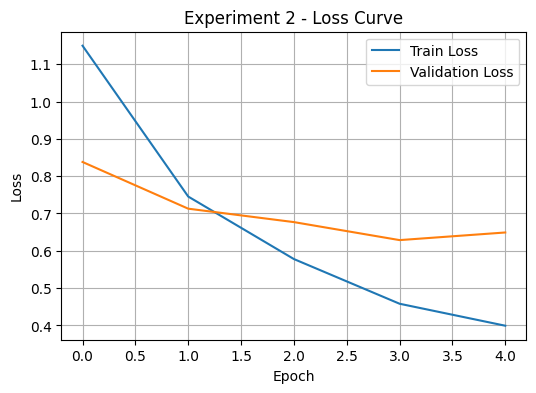

✅ Loss curve saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/exp2_loss_curve.png


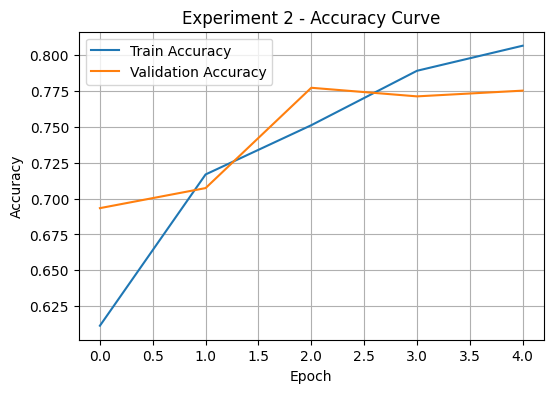

✅ Accuracy curve saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/exp2_accuracy_curve.png


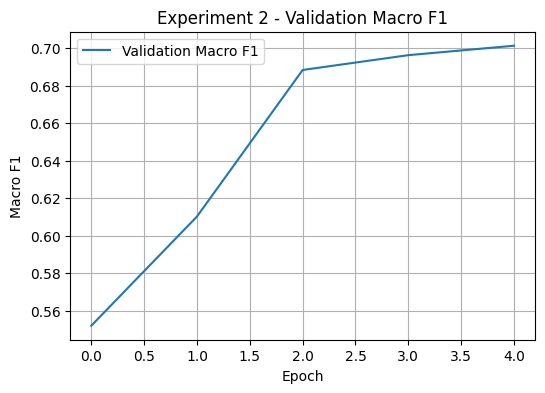

✅ Macro F1 curve saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/exp2_macro_f1_curve.png


In [16]:
# =========================
# Plot training curves (Experiment 2)
# =========================

# LOSS CURVE
plt.figure(figsize=(6,4))
plt.plot(history_ft["train_loss"], label="Train Loss")
plt.plot(history_ft["val_loss"], label="Validation Loss")
plt.title("Experiment 2 - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_path = f"{RESULTS_DIR}/exp2_loss_curve.png"
plt.savefig(loss_path)
plt.show()

print("✅ Loss curve saved to:", loss_path)


# ACCURACY CURVE
plt.figure(figsize=(6,4))
plt.plot(history_ft["train_acc"], label="Train Accuracy")
plt.plot(history_ft["val_acc"], label="Validation Accuracy")
plt.title("Experiment 2 - Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

acc_path = f"{RESULTS_DIR}/exp2_accuracy_curve.png"
plt.savefig(acc_path)
plt.show()

print("✅ Accuracy curve saved to:", acc_path)


# MACRO F1 CURVE
plt.figure(figsize=(6,4))
plt.plot(history_ft["val_f1"], label="Validation Macro F1")
plt.title("Experiment 2 - Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.grid(True)

f1_path = f"{RESULTS_DIR}/exp2_macro_f1_curve.png"
plt.savefig(f1_path)
plt.show()

print("✅ Macro F1 curve saved to:", f1_path)

## Experiment 2: Fine-Tuning the Last ResNet Block

**Date:** March 2026

### Hypothesis
In Experiment 1 the ResNet18 backbone was completely frozen, meaning the pretrained ImageNet features could not adapt to the skin lesion dataset. By unfreezing the final residual block (`layer4`) and allowing it to update during training, the model should better adapt high-level features to dermatoscopic images. This should improve performance, particularly for minority classes.

### Changes from Experiment 1
- Unfroze **ResNet layer4**
- Allowed **layer4 + classifier** to train
- Reduced learning rate to **1e-4** for stable fine-tuning
- Kept **weighted cross-entropy** to address class imbalance
- Same dataset splits and preprocessing pipeline

### LLM Input
The idea of partially unfreezing the pretrained network was suggested by the LLM. The configuration was **modified slightly** by choosing to fine-tune only the final residual block rather than the entire backbone to avoid overfitting.

---

### Results

| Metric | Score |
|------|------|
Training Accuracy | 0.8065 |
Validation Accuracy | 0.7752 |
Best Validation Macro F1 | **0.7012** |

Training curves for **loss, accuracy, and macro F1** were generated and saved for analysis.

---

### Observations
- Validation performance improved consistently across epochs.
- Fine-tuning significantly improved **minority class recognition**, reflected in the large macro F1 improvement.
- The model converged quickly and remained stable during training.
- Validation loss stabilized after epoch 4, suggesting the model is approaching optimal performance.

---

### Comparison to Previous Experiments

| Model | Accuracy | Macro F1 |
|------|------|------|
Random baseline | 0.15 | 0.09 |
Majority class | 0.67 | 0.11 |
Logistic Regression | 0.43 | 0.20 |
Baseline CNN | 0.52 | 0.35 |
Experiment 1 (ResNet18 Frozen) | 0.62 | 0.48 |
**Experiment 2 (ResNet18 Fine-tuned)** | **0.78** | **0.70** |

Fine-tuning dramatically improved performance, especially for class-balanced evaluation metrics.

---

### Conclusions
Allowing the final ResNet block to fine-tune significantly improved model performance. The model was able to adapt pretrained ImageNet features to the characteristics of dermatoscopic images, leading to better classification across all classes.

This confirms that **transfer learning with partial fine-tuning is highly effective for this medical image classification problem**.

---

### Next Steps
The next experiment will explore additional improvements such as:

- stronger **data augmentation**
- **regularization (dropout or weight decay tuning)**
- or testing a **deeper architecture such as ResNet34**

These experiments will determine whether further performance gains can be achieved before selecting the final model.

## Experiment 3: Balanced Mini-Batches with WeightedRandomSampler

In Experiment 2, class imbalance was handled with weighted cross-entropy loss. However, the training batches themselves were still dominated by the majority class (`nv`), which may limit exposure to minority classes during training.

In this experiment, a **WeightedRandomSampler** is used to create more balanced mini-batches while keeping the architecture and fine-tuning strategy the same as Experiment 2.

**Hypothesis:** Balanced sampling should improve validation **Macro F1** by increasing the model’s exposure to minority classes during training.

In [17]:
# =========================
# Experiment 3: WeightedRandomSampler + Fine-tuned ResNet18
# =========================

from torch.utils.data import WeightedRandomSampler

# ---- Slightly stronger train augmentation (optional but still reasonable) ----
train_tfms_exp3 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Rebuild datasets
train_ds_exp3 = HamDataset(train_df, train_tfms_exp3)
val_ds_exp3   = HamDataset(val_df, eval_tfms)

# ---- Weighted sampler based on train labels ----
train_labels = train_df["label"].values
class_sample_counts = np.bincount(train_labels, minlength=len(classes))
class_sample_weights = 1.0 / class_sample_counts
sample_weights = class_sample_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_exp3 = DataLoader(
    train_ds_exp3,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader_exp3 = DataLoader(
    val_ds_exp3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ Weighted sampler ready")

# ---- Model: same as Experiment 2 ----
weights = ResNet18_Weights.DEFAULT
model_exp3 = resnet18(weights=weights)

in_features = model_exp3.fc.in_features
model_exp3.fc = nn.Linear(in_features, len(classes))

# Freeze everything first
for param in model_exp3.parameters():
    param.requires_grad = False

# Unfreeze layer4 + fc
for param in model_exp3.layer4.parameters():
    param.requires_grad = True
for param in model_exp3.fc.parameters():
    param.requires_grad = True

model_exp3 = model_exp3.to(device)

criterion_exp3 = nn.CrossEntropyLoss(weight=class_weights.to(device))

optimizer_exp3 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_exp3.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_exp3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp3, mode="max", factor=0.5, patience=1
)

def train_one_epoch_exp3(model, loader):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer_exp3.zero_grad()
        logits = model(xb)
        loss = criterion_exp3(logits, yb)
        loss.backward()
        optimizer_exp3.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n

@torch.no_grad()
def eval_model_exp3(model, loader):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    all_preds, all_true = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion_exp3(logits, yb)

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)

        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)

        all_preds.append(preds.cpu().numpy())
        all_true.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_true = np.concatenate(all_true)

    acc = total_correct / total_n
    macro_f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)

    return total_loss / total_n, acc, macro_f1

EPOCHS_EXP3 = 5
best_val_f1_exp3 = -1.0
ckpt_path_exp3 = f"{MODELS_DIR}/exp3_resnet18_sampler_best.pt"

history_exp3 = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [], "val_f1": []
}

print("✅ Experiment 3: fine-tuned ResNet18 + weighted sampler")
t0 = time.time()

for epoch in range(1, EPOCHS_EXP3 + 1):
    tr_loss, tr_acc = train_one_epoch_exp3(model_exp3, train_loader_exp3)
    va_loss, va_acc, va_f1 = eval_model_exp3(model_exp3, val_loader_exp3)

    history_exp3["train_loss"].append(tr_loss)
    history_exp3["train_acc"].append(tr_acc)
    history_exp3["val_loss"].append(va_loss)
    history_exp3["val_acc"].append(va_acc)
    history_exp3["val_f1"].append(va_f1)

    scheduler_exp3.step(va_f1)

    print(f"\nEpoch {epoch}/{EPOCHS_EXP3}")
    print(f"Train - loss: {tr_loss:.4f} | acc: {tr_acc:.4f}")
    print(f"Val   - loss: {va_loss:.4f} | acc: {va_acc:.4f} | macro_f1: {va_f1:.4f}")

    if va_f1 > best_val_f1_exp3:
        best_val_f1_exp3 = va_f1
        torch.save({
            "epoch": epoch,
            "model_state": model_exp3.state_dict(),
            "best_val_f1": best_val_f1_exp3,
            "label_map": label_map,
            "classes": classes,
            "img_size": IMG_SIZE
        }, ckpt_path_exp3)
        print(f"💾 Saved best checkpoint: {ckpt_path_exp3} (val_macro_f1={best_val_f1_exp3:.4f})")

print(f"\n✅ Training time: {time.time() - t0:.1f}s")
print("✅ Best Val Macro F1:", round(best_val_f1_exp3, 4))

✅ Weighted sampler ready
✅ Experiment 3: fine-tuned ResNet18 + weighted sampler

Epoch 1/5
Train - loss: 0.4588 | acc: 0.5940
Val   - loss: 1.0396 | acc: 0.3606 | macro_f1: 0.3516
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/exp3_resnet18_sampler_best.pt (val_macro_f1=0.3516)

Epoch 2/5
Train - loss: 0.1789 | acc: 0.7780
Val   - loss: 0.9488 | acc: 0.5065 | macro_f1: 0.4782
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/exp3_resnet18_sampler_best.pt (val_macro_f1=0.4782)

Epoch 3/5
Train - loss: 0.1357 | acc: 0.8215
Val   - loss: 0.8162 | acc: 0.5425 | macro_f1: 0.5006
💾 Saved best checkpoint: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/models/exp3_resnet18_sampler_best.pt (val_macro_f1=0.5006)

Epoch 4/5
Train - loss: 0.1019 | acc: 0.8447
Val   - loss: 0.7216 | acc: 0.5854 | macro_f1: 0.5765
💾 Saved best checkpoint: /content/

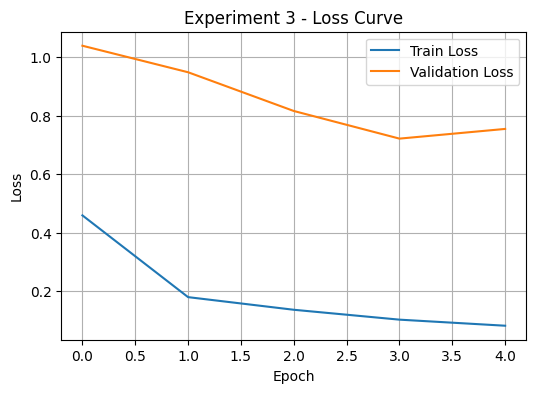

✅ Loss curve saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/exp3_loss_curve.png


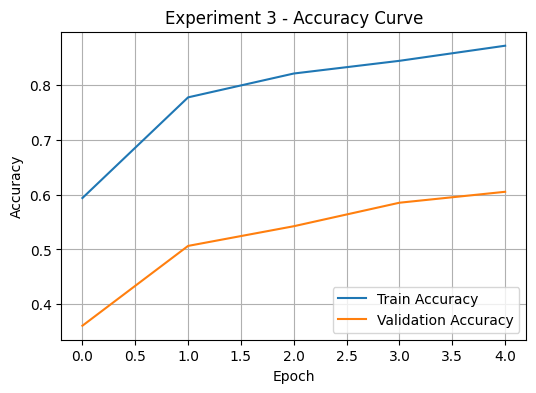

✅ Accuracy curve saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/exp3_accuracy_curve.png


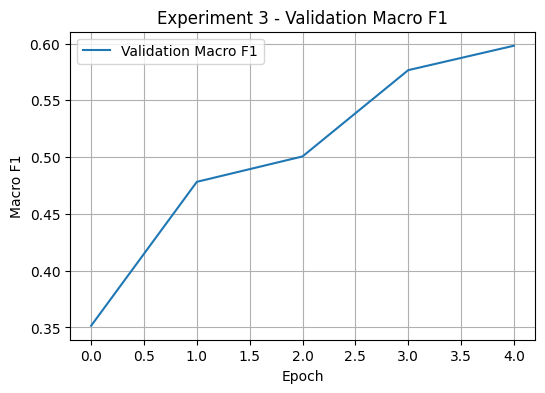

✅ Macro F1 curve saved to: /content/drive/MyDrive/Data science classes/DL/week8/skin-cancer-xai-ham10000/results/exp3_macro_f1_curve.png


In [19]:
# =========================
# Plot training curves (Experiment 3)
# =========================

import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(6,4))
plt.plot(history_exp3["train_loss"], label="Train Loss")
plt.plot(history_exp3["val_loss"], label="Validation Loss")
plt.title("Experiment 3 - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_path = f"{RESULTS_DIR}/exp3_loss_curve.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Loss curve saved to:", loss_path)

# Accuracy
plt.figure(figsize=(6,4))
plt.plot(history_exp3["train_acc"], label="Train Accuracy")
plt.plot(history_exp3["val_acc"], label="Validation Accuracy")
plt.title("Experiment 3 - Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

acc_path = f"{RESULTS_DIR}/exp3_accuracy_curve.png"
plt.savefig(acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Accuracy curve saved to:", acc_path)

# Macro F1
plt.figure(figsize=(6,4))
plt.plot(history_exp3["val_f1"], label="Validation Macro F1")
plt.title("Experiment 3 - Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.grid(True)

f1_path = f"{RESULTS_DIR}/exp3_macro_f1_curve.png"
plt.savefig(f1_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Macro F1 curve saved to:", f1_path)

## Experiment 3: Weighted Sampling with Fine-Tuned ResNet18

**Date:** March 2026  

### Hypothesis
The HAM10000 dataset is highly imbalanced, with the *nevus (nv)* class dominating the dataset. Even though class-weighted loss was used in previous experiments, mini-batches were still dominated by majority-class samples. Using a **WeightedRandomSampler** was expected to produce more balanced mini-batches and improve the model’s ability to learn minority classes, potentially increasing the validation **Macro F1 score**.

### Changes from Experiment 2
- Introduced **WeightedRandomSampler** to create more balanced mini-batches.
- Kept **class-weighted cross-entropy loss**.
- Maintained the same architecture (**ResNet18 fine-tuned on layer4 + fc**).
- Same dataset splits and preprocessing pipeline.

### LLM Input
The weighted sampling approach was suggested by the LLM as a method to further address dataset imbalance. The suggestion was **accepted but evaluated critically** to determine whether it improved minority-class performance.

---

### Results

| Metric | Score |
|------|------|
Training Accuracy | 0.8723 |
Validation Accuracy | 0.6054 |
Best Validation Macro F1 | **0.5981** |

### Observations
- Training accuracy increased quickly, suggesting the model learned rapidly on the sampled data.
- However, validation performance was **lower than Experiment 2**.
- Macro F1 decreased from **0.7012 → 0.5981**.

### Interpretation
Combining **class-weighted loss** with **balanced sampling** likely over-corrected the dataset imbalance. The model was exposed to too many minority-class examples relative to the real distribution, which reduced generalization performance.

### Conclusion
Weighted sampling did **not improve performance** compared to Experiment 2. The best performing configuration remains the **fine-tuned ResNet18 model from Experiment 2**.

### Next Step
Experiment 2 will be selected as the **final model candidate**, and evaluation will proceed on the held-out **test dataset** for final performance reporting.

### Experiment Summary

Experiment 2 achieved the highest validation Macro F1 score (0.7012) and demonstrated the best generalization performance. Experiment 3 attempted to improve minority class representation using weighted sampling but resulted in reduced validation performance.

Therefore, the fine-tuned ResNet18 model from Experiment 2 is selected as the final model for evaluation on the held-out test set in the next stage of the project.